In [1]:
import torch
import CT.Models.misc as misc
import CT.Inference.Kolmogorov.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lag_ratio = 1
SNS_NS_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260120_155052-z9dfjikj/files/checkpoint_last.p"
# SNS_NS_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260202_173803-x6tx17te/files/checkpoint_last.p"
SNS_NS = misc.load_SNS(SNS_NS_file_path).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [2]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p", weights_only=True)
data = data_dict["data"]/4.44
data = data.to(device)

In [3]:
x = data[0:1].to(device)
x_t = x[:,1:2]
short_lag = torch.tensor([1]).to(device)
x_short = x[:,0:1].to(device)
s_short = 900
x_short_noised = SNS_NS._forward_diffusion(x_short, s_short).to(device)
s_t = 999
x_t_noised = SNS_NS._forward_diffusion(x_t, s_t).to(device)

x_in = torch.cat((x[:,-1:], x_short_noised, x_t_noised),dim = 1)
pred_s = SNS_NS.model.ratio_class_both(x_in, None, None, None).to(device)
print(pred_s)
denoised = SNS_NS.denoising_left_down(x_in, pred_s, forward_diff = False, stop = 0)

tensor([[884, 989]], device='cuda:0')


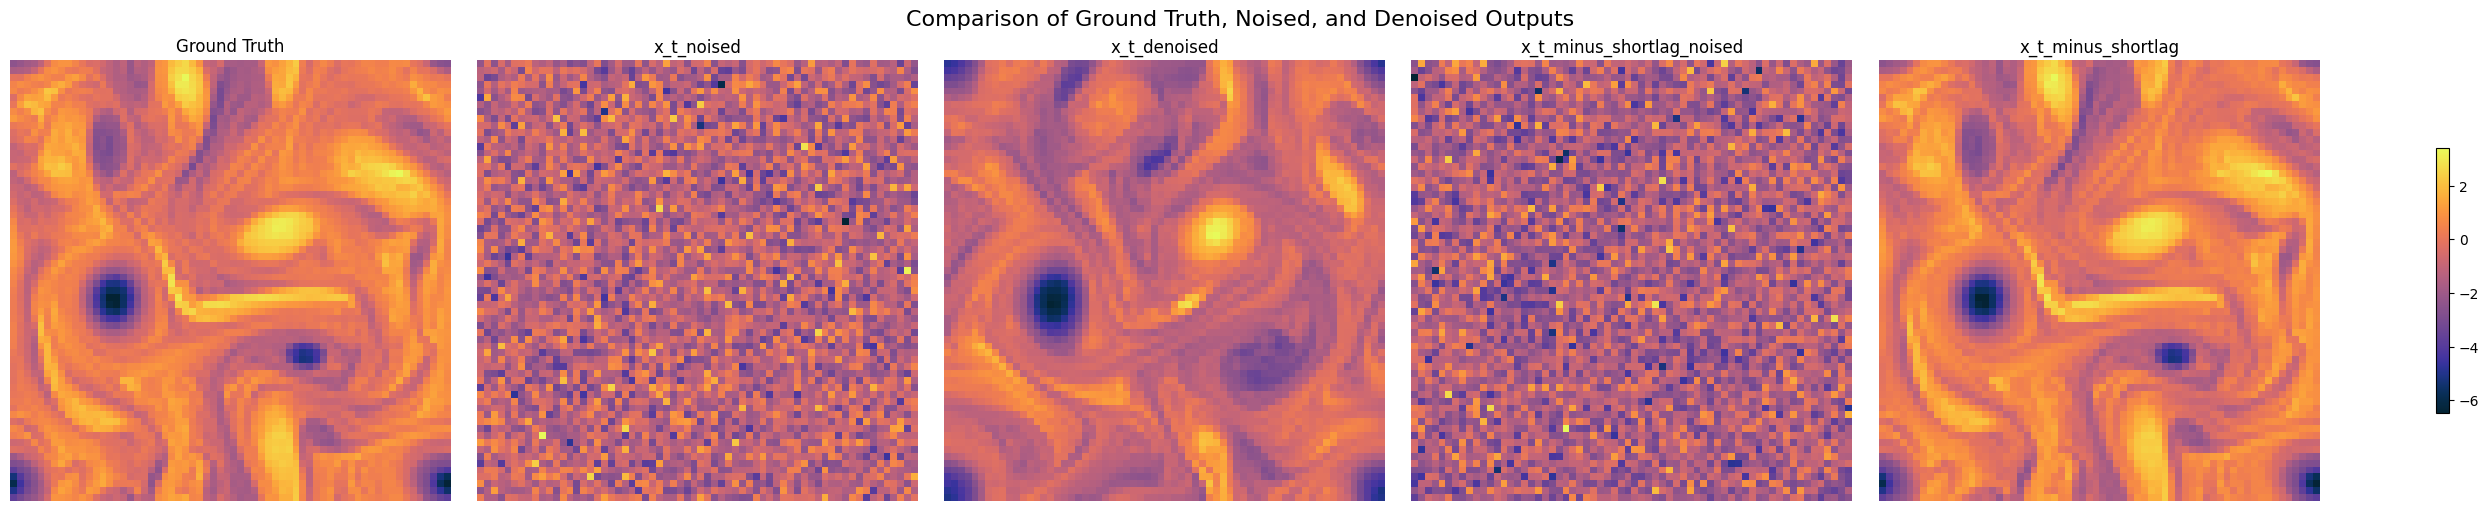

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t,                
    x_t_noised,
    denoised[:,-1:],
    x_short_noised,
    x_short
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag_noised',
    'x_t_minus_shortlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()


Noise levels: 100%|██████████| 200/200 [00:01<00:00, 117.43it/s]


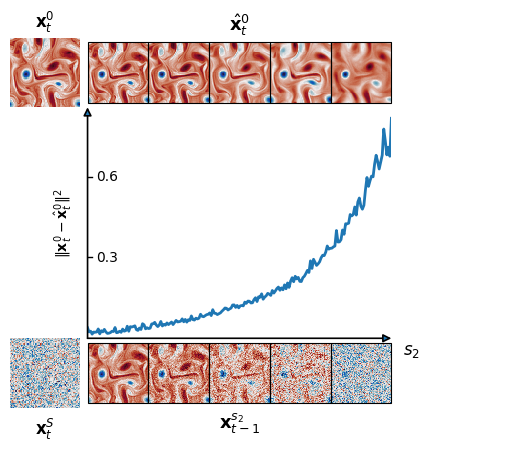

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import cmocean

# ============================================================
# Helpers
# ============================================================
def make_noise_schedule(max_level: int, skip_ratio: float = 1.0):
    if not (0 < skip_ratio <= 1.0):
        raise ValueError("skip_ratio must be in (0, 1].")
    stride = max(1, int(round(1.0 / skip_ratio)))
    return list(range(0, max_level, stride))


def _as_batch_timesteps(t, batch_size: int, device):
    if isinstance(t, int):
        return torch.full((batch_size,), t, device=device, dtype=torch.int64)
    if torch.is_tensor(t):
        t = t.to(device=device, dtype=torch.int64)
        if t.ndim == 0:
            return torch.full((batch_size,), int(t.item()), device=device, dtype=torch.int64)
        return t
    raise TypeError(f"Unsupported t type: {type(t)}")


@torch.no_grad()
def tweedie_mean_x0_from_eps(sns_ns, x_t_noised, t, eps_hat):
    B = x_t_noised.shape[0]
    device = x_t_noised.device
    t = _as_batch_timesteps(t, B, device)

    a_bar = sns_ns.alphas_cumprod.gather(-1, t).reshape(B, 1, 1, 1)
    sqrt_a_bar = torch.sqrt(a_bar)
    sqrt_one_minus = torch.sqrt(torch.clamp(1.0 - a_bar, min=0.0))

    return (x_t_noised - sqrt_one_minus * eps_hat) / torch.clamp(sqrt_a_bar, 1e-12)


@torch.no_grad()
def eval_mse_over_noise_levels_tweedie(
    SNS_NS,
    data,
    device,
    sample_cols,
    max_noise_level=999,
    s_t=900,
    skip_ratio=1.0,
):
    SNS_NS.model.eval()
    levels = make_noise_schedule(max_noise_level, skip_ratio)
    mse_per_level = []

    for s_short in tqdm(levels, desc="Noise levels", leave=True):
        losses = []
        for j in sample_cols:
            x_pair = data[:, j - 1 : j + 1].to(device)
            x_short = x_pair[:, 0:1]
            x_t_clean = x_pair[:, 1:2]
            x_long = data[:, j - 2 : j - 1].to(device) if j >= 2 else x_short

            x_short_noised = SNS_NS._forward_diffusion(x_short, s_short)
            x_t_noised = SNS_NS._forward_diffusion(x_t_clean, s_t)

            x_cond = torch.cat((x_long, x_short_noised, x_t_noised), dim=1)
            eps_pred_all = SNS_NS.model(x_cond, None, None, None, False)
            eps_t_hat = eps_pred_all[:, -1:]

            x_t_hat = tweedie_mean_x0_from_eps(SNS_NS, x_t_noised, s_t, eps_t_hat)
            losses.append(F.mse_loss(x_t_hat, x_t_clean).item())

        mse_per_level.append(sum(losses) / len(losses))

    return levels, mse_per_level


@torch.no_grad()
def collect_xshort_and_tweedie_visuals(
    SNS_NS,
    data,
    device,
    sample_col,
    s_short_list,
    s_t=900,
    member_idx=0,
):
    SNS_NS.model.eval()

    x_pair = data[:, sample_col - 1 : sample_col + 1].to(device)
    x_short = x_pair[:, 0:1]
    x_t_clean = x_pair[:, 1:2]
    x_long = data[:, sample_col - 2 : sample_col - 1].to(device) if sample_col >= 2 else x_short

    xshort_noised = {}
    xt_tweedie = {}

    for s_short in s_short_list:
        s_short = int(s_short)

        xs_noised = SNS_NS._forward_diffusion(x_short, s_short)
        xt_noised = SNS_NS._forward_diffusion(x_t_clean, s_t)

        x_cond = torch.cat((x_long, xs_noised, xt_noised), dim=1)
        eps_pred_all = SNS_NS.model(x_cond, None, None, None, False)
        eps_t_hat = eps_pred_all[:, -1:]

        xt_hat = tweedie_mean_x0_from_eps(SNS_NS, xt_noised, s_t, eps_t_hat)

        xshort_noised[s_short] = xs_noised[member_idx].detach().cpu()
        xt_tweedie[s_short] = xt_hat[member_idx].detach().cpu()

    return xshort_noised, xt_tweedie


@torch.no_grad()
def get_true_xt_and_noised_xt(data, device, sample_col: int, s_t: int, member_idx: int = 0):
    x_pair = data[:, sample_col - 1 : sample_col + 1].to(device)
    x_t_clean = x_pair[:, 1:2]
    x_t_noised = SNS_NS._forward_diffusion(x_t_clean, s_t)
    return x_t_clean[member_idx].detach().cpu(), x_t_noised[member_idx].detach().cpu()


def make_arrow_axes(ax, x_end, y_end, lw=1.2, ms=12):
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    arrowprops = dict(arrowstyle="-|>", lw=lw, mutation_scale=ms, shrinkA=0, shrinkB=0)
    ax.annotate("", xy=(x_end, 0), xytext=(0, 0), arrowprops=arrowprops, clip_on=False)
    ax.annotate("", xy=(0, y_end), xytext=(0, 0), arrowprops=arrowprops, clip_on=False)


def draw_y_ticks_right_of_axis(ax, y_ticks, tick_len_frac=0.015, text_dx_pts=6, fs=10):
    x0, x1 = ax.get_xlim()
    tick_len = (x1 - x0) * tick_len_frac
    for y in y_ticks:
        ax.plot([0, 0 + tick_len], [y, y], lw=1.0, color="black", clip_on=False)
        ax.annotate(
            f"{y:g}",
            xy=(0, y),
            xytext=(text_dx_pts, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=fs,
            clip_on=False,
        )


def style_strip(ax_strip, n_tiles, edgecolor="black", lw=0.8):
    ax_strip.set_axis_off()
    for i in range(n_tiles):
        rect = plt.Rectangle(
            (i, -1.0), 1.0, 1.0,
            fill=False, edgecolor=edgecolor, linewidth=lw,
            zorder=10, clip_on=False
        )
        ax_strip.add_patch(rect)


def style_single_image(ax_img, edgecolor="black", lw=0.8):
    ax_img.set_axis_off()
    for s in ax_img.spines.values():
        s.set_visible(True)
        s.set_edgecolor(edgecolor)
        s.set_linewidth(lw)


# ============================================================
# Run evaluation + visuals
# ============================================================
test_times = [67]
s_t = 900
cmap = cmocean.cm.balance  # <-- white–red–blue colormap

levels, mse_vals = eval_mse_over_noise_levels_tweedie(
    SNS_NS=SNS_NS,
    data=data,
    device=device,
    sample_cols=test_times,
    max_noise_level=999,
    s_t=s_t,
    skip_ratio=0.2,
)

bins = [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1000)]
viz_levels = [min(int(0.5 * (a + b)), 998) for a, b in bins]

xshort_viz, tweedie_viz = collect_xshort_and_tweedie_visuals(
    SNS_NS=SNS_NS,
    data=data,
    device=device,
    sample_col=test_times[0],
    s_short_list=viz_levels,
    s_t=s_t,
    member_idx=0,
)

x_t_true, x_t_noised = get_true_xt_and_noised_xt(
    data=data,
    device=device,
    sample_col=test_times[0],
    s_t=s_t,
    member_idx=0,
)

# ============================================================
# Plot
# ============================================================
fig = plt.figure()

gs = fig.add_gridspec(
    3, 3,
    width_ratios=[0.24, 1.0, 0.35],
    height_ratios=[0.9, 3.0, 0.9],
    wspace=0.04,
    hspace=0.00,
)

pad = fig.add_subplot(gs[:, 2])
pad.axis("off")

# --- Top-left: true x_t^0 ---
ax_true = fig.add_subplot(gs[0, 0])
ax_true.imshow(x_t_true.squeeze().numpy(), cmap=cmap, interpolation="nearest")
style_single_image(ax_true)
ax_true.text(0.5, 1.05, r"$\mathbf{x}_t^0$", transform=ax_true.transAxes,
             ha="center", va="bottom", fontsize=12)

# --- Top-right: predicted strip ---
ax_pred = fig.add_subplot(gs[0, 1])
ax_pred.set_xlim(0.0, 5.0)
ax_pred.set_ylim(-1.0, 0.0)

for i, s_rep in enumerate(viz_levels):
    ax_pred.imshow(
        tweedie_viz[int(s_rep)].squeeze().numpy(),
        extent=[i, i + 1, -1.0, 0.0],
        aspect="equal",
        cmap=cmap,
        interpolation="nearest",
    )

style_strip(ax_pred, n_tiles=5)
ax_pred.text(2.5, 0.08, r"$\hat{\mathbf{x}}_t^0$",
             ha="center", va="bottom", fontsize=13, transform=ax_pred.transData)

# --- Middle-right: MSE plot ---
ax = fig.add_subplot(gs[1, 1])
xmax = float(max(levels))
ymax = max(float(max(mse_vals)) * 1.05, 0.7)

ax.plot(levels, mse_vals, lw=2)
ax.set_xlim(0.0, xmax)
ax.set_ylim(0.0, ymax)

make_arrow_axes(ax, x_end=xmax, y_end=ymax)
draw_y_ticks_right_of_axis(ax, [0.3, 0.6])

ax.set_ylabel(r"$\|\mathbf{x}_t^0 - \hat{\mathbf{x}}_t^0\|^2$", labelpad=10)
ax.annotate(r"$s_2$", xy=(xmax, 0.0), xytext=(8, -2),
            textcoords="offset points", ha="left", va="top", fontsize=12)

# --- Bottom-left: noised x_t^S ---
ax_noised = fig.add_subplot(gs[2, 0])
ax_noised.imshow(x_t_noised.squeeze().numpy(), cmap=cmap, interpolation="nearest")
style_single_image(ax_noised)
ax_noised.text(0.5, -0.12, r"$\mathbf{x}_t^S$",
               transform=ax_noised.transAxes, ha="center", va="top", fontsize=12)

# --- Bottom-right: x_{t-1}^{s2} strip ---
ax_bot = fig.add_subplot(gs[2, 1])
ax_bot.set_xlim(0.0, 5.0)
ax_bot.set_ylim(-1.0, 0.0)

pos_mid = ax.get_position()
pos_bot = ax_bot.get_position()
ax_bot.set_position([pos_bot.x0, pos_mid.y0 - pos_bot.height, pos_bot.width, pos_bot.height])

pos_noi = ax_noised.get_position()
ax_noised.set_position([pos_noi.x0, pos_mid.y0 - pos_noi.height, pos_noi.width, pos_noi.height])

eps = 0.02
for i, s_rep in enumerate(viz_levels):
    ax_bot.imshow(
        xshort_viz[int(s_rep)].squeeze().numpy(),
        extent=[i, i + 1, -1.0, 0.0 + eps],
        aspect="equal",
        cmap=cmap,
        interpolation="nearest",
    )

style_strip(ax_bot, n_tiles=5)
ax_bot.text(2.5, -1.12, r"$\mathbf{x}_{t-1}^{s_2}$",
            ha="center", va="top", fontsize=13, transform=ax_bot.transData)

plt.savefig("figure_balance_colormap.png", dpi=300, bbox_inches="tight")
plt.show()


In [6]:
x = data[:,0:1].to(device)
del data, data_dict
Emu_file_path = "/scratch/ql2221/Emulator_models/wandb_data/wandb/run-20251209_020651-5dziwzqp/files/checkpoint_best.p"
Emu = misc.load_Emulator(Emu_file_path).to(device)
SNS_NS.model.eval()
Emu.eval()
rollout, s_shorts, s_t = performance.SNS_NS_refinement(x, Emu, SNS_NS, n_steps=50000, sigma=None, silence=False, forward_diff = True, denoise_mode = "left_down", device = "cuda")

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)
100%|██████████| 49999

In [7]:
torch.save(s_shorts, "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/pred_s_short_structure.p")
torch.save(s_t, "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/pred_s_t_structure.p")

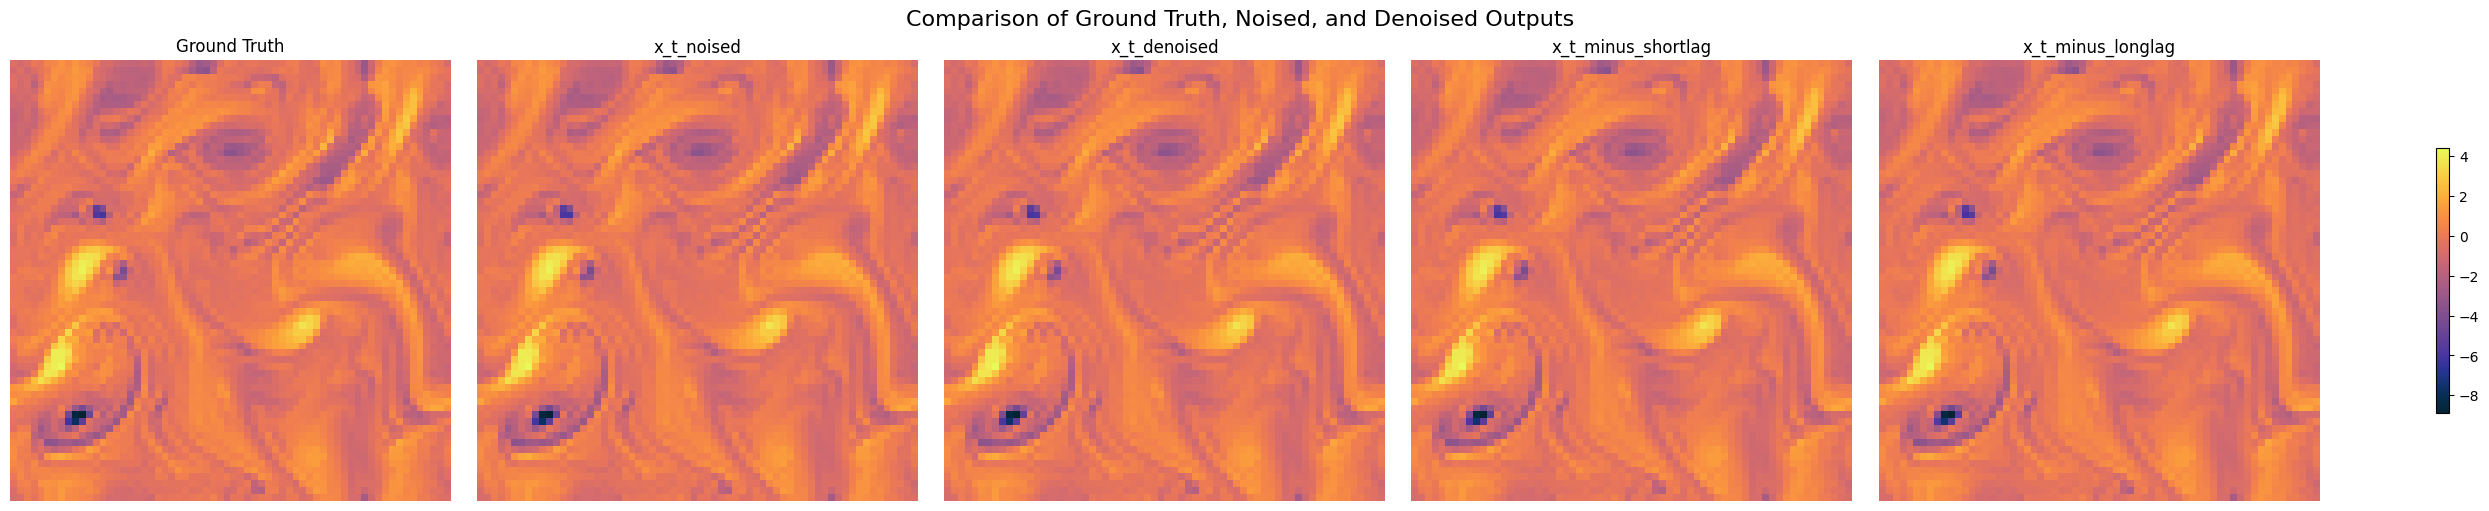

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
T = 30000
B = 4

tensors = [
    rollout[B:B+1, T-5:T-4],
    rollout[B:B+1, T-4:T-3],
    rollout[B:B+1, T-3:T-2],
    rollout[B:B+1, T-2:T-1],
    rollout[B:B+1, T-1:T],
]

titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
emu_rollout = performance.run_emu(x[:,0:1],emu = Emu, n_steps=30000,silent=False,sigma=None)

100%|██████████| 29999/29999 [02:34<00:00, 194.00it/s]


In [9]:
torch.save(rollout, "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/FINAL_PAPER_FIXSHORT.p")

In [18]:
torch.save(emu_rollout, "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/FINAL_PAPER_EMU.p")

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
emu_rollout = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/FINAL_PAPER_EMU.p")[0:5].to(device)
rollout =  torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/FINAL_PAPER_LEFTDOWN.p")[0:5].to(device)
data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p")
data = data_dict["data"]/4.44
x = data[0:5].to(device)

tensor = torch.cat((x[:,:emu_rollout.shape[1]], emu_rollout, rollout), dim = 0)
titles = [ "Numerical", "Numerical", "Numerical", "Numerical", "Numerical", "Gaussian", "Gaussian", "Gaussian", "Gaussian", "Gaussian", "SNS", "SNS", "SNS", "SNS", "SNS"]

/state/partition1/job-1627655/ipykernel_915671/3283943838.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emu_rollout = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_f

In [ ]:
# tensor = torch.cat((x[:,:emu_rollout.shape[1]], emu_rollout, rollout), dim = 0)
# torch.save(tensor, "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/SNS_SNS_ICML.p")

titles = [ "Numerical", "Numerical", "Numerical", "Numerical", "Numerical", "Gaussian", "Gaussian", "Gaussian", "Gaussian", "Gaussian", "SNS", "SNS", "SNS", "SNS", "SNS"]

In [2]:
import numpy as np
import matplotlib
matplotlib.use("Agg")  # headless / non-interactive backend for rendering frames
import matplotlib.pyplot as plt

from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
from tqdm import tqdm


def make_movie_moviepy(
    state_vector,
    save_path="emulator_movie.mp4",
    fps=30,
    vmin=None,
    vmax=None,
    stride=10,
    titles=None,
    cmap="viridis",
    interpolation="nearest",
    dpi=150,
    bitrate="20000k",
):
    """
    Create a 3x5 grid movie from a 4D tensor/array of shape (B, T, H, W), using only every `stride`-th frame.
    - B must be 15 (3 rows x 5 columns).
    - One shared colorbar per row (fixed over time).
    - Optional custom title per panel via `titles` (len 15, row-major).

    Uses MoviePy's FFmpeg writer (FFmpeg required for MP4).
    """

    # Convert to numpy without requiring torch as a dependency at import time
    if hasattr(state_vector, "detach"):  # likely a torch.Tensor
        arr = state_vector.detach().cpu().numpy()
    else:
        arr = np.asarray(state_vector)

    if arr.ndim != 4:
        raise ValueError(f"Expected [B, T, H, W], got {arr.shape}")
    B, T, H, W = arr.shape
    if B != 15:
        raise ValueError(f"B must be 15 for a 3x5 grid, got B={B}")
    if T < 1:
        raise ValueError("T must be >= 1")

    # Frame indices to use
    stride = max(1, int(stride))
    frame_indices = list(range(0, T, stride))
    if frame_indices[-1] != T - 1:
        frame_indices.append(T - 1)  # ensure last frame is included

    def bidx(r, c):
        return r * 5 + c

    # Determine color limits
    row_limits = []
    if vmin is not None or vmax is not None:
        gmin, gmax = vmin, vmax
        if gmin is None or gmax is None:
            used = arr[:, frame_indices, :, :]
            amin = float(np.nanmin(used))
            amax = float(np.nanmax(used))
            if gmin is None:
                gmin = amin
            if gmax is None:
                gmax = amax
        row_limits = [(gmin, gmax)] * 3
    else:
        for r in range(3):
            row_data = arr[bidx(r, 0):bidx(r, 0) + 5, :, :, :]  # [5, T, H, W]
            row_used = row_data[:, frame_indices, :, :]
            rmin = float(np.nanmin(row_used))
            rmax = float(np.nanmax(row_used))
            row_limits.append((rmin, rmax))

    # Titles
    if titles is None:
        titles = [f"Panel {i+1}" for i in range(15)]
    if len(titles) != 15:
        raise ValueError("`titles` must have length 15 (row-major order).")

    # Figure and axes (reserve right margin for colorbars)
    fig, axes = plt.subplots(3, 5, figsize=(15, 9), dpi=dpi, squeeze=False)
    fig.subplots_adjust(
        left=0.03, right=0.88, top=0.92, bottom=0.05,
        wspace=0.03, hspace=0.15
    )

    ims = []
    for r in range(3):
        vmin_r, vmax_r = row_limits[r]

        # Create images for this row
        for c in range(5):
            ax = axes[r, c]
            im = ax.imshow(
                arr[bidx(r, c), frame_indices[0]],
                cmap=cmap,
                vmin=vmin_r,
                vmax=vmax_r,
                interpolation=interpolation,
                origin="upper",
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(titles[bidx(r, c)], fontsize=10)
            ims.append(im)

        # Colorbar axis placed to the right of the last subplot in this row
        last_ax = axes[r, -1]
        pos = last_ax.get_position()  # figure coordinates

        pad = 0.01
        cbar_w = 0.015
        cax = fig.add_axes([pos.x1 + pad, pos.y0, cbar_w, pos.height])

        cb = fig.colorbar(ims[r * 5], cax=cax)
        cb.set_label(
            f"Row {r+1} scale [{row_limits[r][0]:.3g}, {row_limits[r][1]:.3g}]",
            fontsize=9,
        )

    suptitle = fig.suptitle(f"Timestep {frame_indices[0]}", fontsize=12)

    # Prepare canvas once
    fig.canvas.draw()

    # Helper: render current figure to RGB array (Matplotlib 3.8+ compatible)
    def fig_to_rgb():
        fig.canvas.draw()
        buf = np.asarray(fig.canvas.buffer_rgba())
        return buf[:, :, :3].copy()  # drop alpha channel

    # Update plots for frame i
    def update(i):
        f = frame_indices[i]
        for r in range(3):
            for c in range(5):
                ims[r * 5 + c].set_data(arr[bidx(r, c), f])
        suptitle.set_text(f"Timestep {f}")

    # Get frame size for writer
    first_frame = fig_to_rgb()
    height, width = first_frame.shape[:2]

    # MoviePy low-level writer
    writer = FFMPEG_VideoWriter(
        filename=save_path,
        size=(width, height),
        fps=fps,
        codec="libx264",
        bitrate=bitrate,
        preset="medium",
        ffmpeg_params=["-pix_fmt", "yuv420p"],
    )

    try:
        for i in tqdm(range(len(frame_indices)), desc="Rendering movie"):
            update(i)
            frame = fig_to_rgb()
            writer.write_frame(frame)
    finally:
        writer.close()
        plt.close(fig)

    print(f"Movie saved: {save_path}")


In [3]:
titles = [ "Numerical", "Numerical", "Numerical", "Numerical", "Numerical", "Gaussian", "Gaussian", "Gaussian", "Gaussian", "Gaussian", "SNS", "SNS", "SNS", "SNS", "SNS"]
make_movie_moviepy(
    state_vector=tensor,
    save_path="Pre.mp4",
    fps=30,
    stride=10,       
    titles=titles,
    cmap="viridis",
    dpi=300,
    vmin=-4,
    vmax=4,
)

/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
Rendering movie: 100%|██████████| 5001/5001 [46:48<00:00,  1.78it/s]


Movie saved: Pre.mp4


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---- load ----
path = "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/SNS_inference_2.p"
tensor = torch.load(path, map_location="cpu")

# Expect shape: (15, T, 64, 64)
assert tensor.ndim == 4 and tensor.shape[0] == 15, f"Unexpected shape: {tuple(tensor.shape)}"
B, T, H, W = tensor.shape
assert (H, W) == (64, 64), f"Unexpected spatial size: {(H, W)}"

# ---- split ----
sns = tensor[0:5]       # (5, T, 64, 64)
sur = tensor[5:10]      # (5, T, 64, 64)
ours = tensor[10:15]    # (5, T, 64, 64)

# ---- MSE vs time (paired: i-th pred vs i-th sns) ----
# mse_i(t) = mean_{x,y} (pred_i(t,x,y) - sns_i(t,x,y))^2
def mse_vs_time(pred, gt):
    # pred, gt: (5, T, H, W)
    err2 = (pred - gt) ** 2
    return err2.mean(dim=(2, 3))  # (5, T)

mse_sur = mse_vs_time(sur, sns)     # (5, T)
mse_ours = mse_vs_time(ours, sns)   # (5, T)

# Convert to numpy for plotting
mse_sur_np = mse_sur.numpy()
mse_ours_np = mse_ours.numpy()
t = np.arange(T)

# ---- plot ----
plt.figure(figsize=(6.2, 4.6), dpi=150)

# Surrogate (grey) and Our method (blue) — similar to your example
for i in range(5):
    plt.semilogy(t, mse_sur_np[i], color="0.5", alpha=0.9, linewidth=1.2)
for i in range(5):
    plt.semilogy(t, mse_ours_np[i], color="blue", alpha=0.65, linewidth=1.2)

plt.title("Kolmogorov: Unet")
plt.ylabel("MSE")
plt.xlabel("time")

# Optional: match a typical log-range like your screenshot
# Uncomment if desired:
# plt.ylim(1e-2, 1e2)

plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)

# Legend with representative lines
plt.plot([], [], color="0.5", linewidth=2, label="Emulator")
plt.plot([], [], color="blue", linewidth=2, label="Thermalized")
plt.legend(frameon=True, loc="upper right")

plt.tight_layout()
plt.savefig("mse_vs_time_kolmogorov_unet.png", bbox_inches="tight")
plt.show()

print("Saved: mse_vs_time_kolmogorov_unet.png")


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def _history_list_to_1d_numpy(history, max_points=None):
    """
    history: list of tensors, each typically [B, 1] or [B]
    returns: 1D numpy array of all values concatenated over time and batch
    """
    if len(history) == 0:
        return np.array([], dtype=np.float32)

    # Stack along time: [T, B, 1] or [T, B]
    h = torch.stack(history, dim=0)

    # Squeeze trailing singleton dims -> [T, B]
    h = h.squeeze(-1)

    # Move to CPU and flatten -> [T*B]
    x = h.detach().to("cpu").reshape(-1)

    # Optional subsample for speed / memory
    if max_points is not None and x.numel() > max_points:
        idx = torch.randperm(x.numel(), device=x.device)[:max_points]
        x = x[idx]

    return x.numpy()


def plot_overlay_hist_s_short_s_t(
    s_short_history,
    s_t_history,
    bins=40,
    range=None,               # e.g. (0, 1) if your s are bounded; else None
    density=False,
    max_points=2_000_000,     # prevent huge memory if n_steps*B is massive
    color_short="#1f77b4",    # blue
    color_t="#ff7f0e",        # orange
    alpha_short=0.55,
    alpha_t=0.55,
    label_short=r"$s_{\mathrm{short}}$",
    label_t=r"$s_t$",
    title=None,
    xlabel="value",
    ylabel="count",
    savepath=None,
    show=True,
):
    """
    Overlay histograms for s_short and s_t histories (stacked over time & batch).

    Notes:
      - If you run 50k steps with decent B, you probably want max_points or stride.
      - Uses shared bins so the overlays are comparable.
    """
    xs = _history_list_to_1d_numpy(s_short_history, max_points=max_points)
    xt = _history_list_to_1d_numpy(s_t_history,     max_points=max_points)

    if xs.size == 0 or xt.size == 0:
        raise ValueError("Empty history: got no values to plot.")

    # Shared bin edges: use global min/max unless user provided range
    if range is None:
        lo = float(min(xs.min(), xt.min()))
        hi = float(max(xs.max(), xt.max()))
        # guard against degenerate range
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = lo - 1.0, hi + 1.0
        range = (lo, hi)

    bin_edges = np.histogram_bin_edges(np.concatenate([xs, xt]), bins=bins, range=range)

    fig, ax = plt.subplots(figsize=(4.2, 3.6), dpi=150)

    ax.hist(
        xs, bins=bin_edges, density=density,
        alpha=alpha_short, color=color_short, label=label_short
    )
    ax.hist(
        xt, bins=bin_edges, density=density,
        alpha=alpha_t, color=color_t, label=label_t
    )

    ax.legend(frameon=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density" if density else ylabel)
    if title is not None:
        ax.set_title(title)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300)
    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


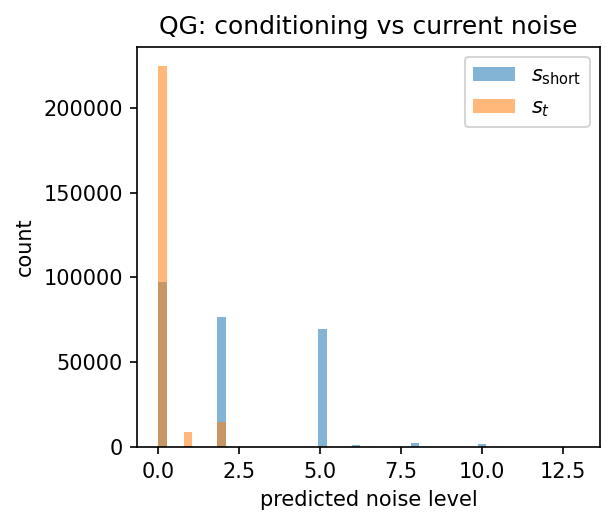

(<Figure size 630x540 with 1 Axes>,
 <Axes: title={'center': 'QG: conditioning vs current noise'}, xlabel='predicted noise level', ylabel='count'>)

In [9]:
plot_overlay_hist_s_short_s_t(
    s_shorts, s_t,
    bins=50,
    density=False,
    title="QG: conditioning vs current noise",
    xlabel="predicted noise level",
    savepath="s_levels_overlay.png",
)

In [24]:
bins = 
s_short_count = array
for i in range(bins):
    for j in range(50000/bins):
        s_short_count[i] += s_short[]
        

TypeError: only integer tensors of a single element can be converted to an index